In [38]:
from matplotlib import pyplot as plt
import json

from pathlib import Path

import pandas as pd

from scipy.stats import sem

In [12]:
DIR = Path("../../artifacts/2023-08-s11/experiments/accuracy_basis")

In [41]:
def load(dataset, experiment_group, logit_mod, arch, layer, basis_name, basis_mode, seeds=list(range(1, 5+1))):
    
    arr_dfs = []
    for seed in seeds:
        with open(DIR  / experiment_group / f"{dataset}-seed{seed}" / f"logit-mod-{logit_mod}" / arch / layer / f"{basis_name}--{basis_mode}" / "stats.json", "r") as fh:
            data = json.load(fh)
            
        
        df = pd.DataFrame(
            {
                "acc": data["arr_acc"],
                "k": data["arr_ks"]
            }
        )
        df["dims"] = data["dims"]

        # remark: the attribute name here is misnormzer. 
        # perhaps, we refactor it.
        df["original_acc"] = data["original_acc"]
        df["seed"] = seed
            
        arr_dfs.append(df)
    
    df = pd.concat(arr_dfs).groupby(by="k").agg({
        "acc": ["mean", "std"],
        "seed": ["count"],
        "original_acc": ["first"],
        "dims": ["first"]
    })
    
    
    assert (df["seed"]["count"] == df["seed"]["count"].values[0]).all()

    for col in ["original_acc", "dims"]:

        assert (df[col]["first"] == df[col]["first"].values[0]).all()

    return df.reset_index()

load(
    dataset="cifar100-people--ts1.0", 
    logit_mod="oneclass", 
    arch="cifar100-resnet18-p1",
    layer="layer4", 
    basis_name="prca", 
    basis_mode="centered",
    seeds=range(1, 5+1),
    experiment_group="comparing-prca-variants"
)

k     acc            seed original_acc  dims
           mean       std count        first first
0     1  0.3660  0.000000     5         0.55   512
1     2  0.5004  0.000894     5         0.55   512
2     3  0.5440  0.000000     5         0.55   512
3     4  0.5520  0.000000     5         0.55   512
4     5  0.5560  0.000000     5         0.55   512
5     6  0.5580  0.000000     5         0.55   512
6     7  0.5580  0.000000     5         0.55   512
7     8  0.5580  0.000000     5         0.55   512
8     9  0.5560  0.000000     5         0.55   512
9    10  0.5580  0.000000     5         0.55   512
10   11  0.5600  0.000000     5         0.55   512
11   12  0.5560  0.000000     5         0.55   512
12   13  0.5540  0.000000     5         0.55   512
13   14  0.5540  0.000000     5         0.55   512
14   15  0.5540  0.000000     5         0.55   512
15   16  0.5540  0.000000     5         0.55   512
16   17  0.5540  0.000000     5         0.55   512
17   18  0.5540  0.000000     5         0.55   512
18   19  0.5556  0.000894     5         0.55   512
19   20  0.5540  0.000000     5         0.55   512
20   21  0.5540  0.000000     5         0.55   512
21   22  0.5540  0.000000     5         0.55   512
22   23  0.5540  0.000000     5         0.55   512
23   24  0.5560  0.000000     5         0.55   512
24   25  0.5540  0.000000     5         0.55   512
25   26  0.5540  0.000000     5         0.55   512
26   27  0.5540  0.000000     5         0.55   512
27   28  0.5540  0.000000     5         0.55   512
28   29  0.5540  0.000000     5         0.55   512
29   30  0.5524  0.000894     5         0.55   512
30   31  0.5540  0.000000     5         0.55   512
31   32  0.5540  0.000000     5         0.55   512
32   64  0.5540  0.000000     5         0.55   512
33  128  0.5540  0.000000     5         0.55   512
34  256  0.5540  0.000000     5         0.55   512
35  512  0.5500  0.000000     5         0.55   512

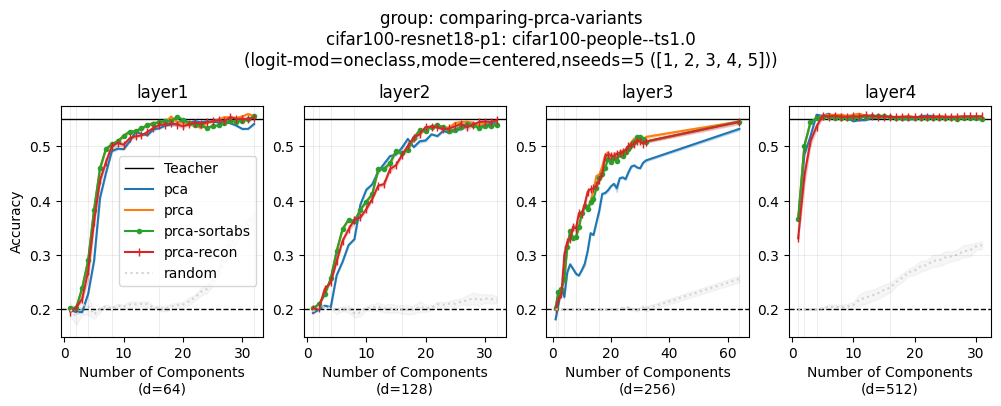

In [60]:
import numpy as np 

def color(name):
    if "random" in name:
        return "lightgray"
    elif name == "rel-abs"  or name == "act-abs":
        return plt.gca().lines[-1].get_color()
#     elif "pca" in name:
#         return "blue"
#     elif "prca" in name:
#         return "red"
    else:
        return None

def marker(name):
    if name in ["prca-abs", "prca-recon"]:
        return "|"
    elif name in ["prca-v2", "prca-sortabs"]:
        return "."
    elif "pcaprca" in name:
        return "."
    elif name in ["rel-abs", "act-abs"]:
        return "x"
    elif name == "random":
        return None
    else:
        return None

    
def alias(name):
    
    if name == "prca-v2":
        return "prca-sortabs"
    else:
        return name
    

def ls(name):
    if "rel" in name or "act" in name:
        return "--"
    elif "random" in name:
        return ":"
    else:
        return "-"
def viz_oneclass(
    arch,
    dataset,
    experiment_group,
    training_size=1.0, 
    logit_mod="oneclass",
    basis_mode="centered", 
    layers=["layer3", "layer4"],
    basis_names=[
        "pca",
        "prca",
        "prca-v2",
        "prca-recon",
        "random", 
        
    ],
    seeds=list(range(1, 5+1)),
):
    
    dataset =  f"{dataset}--ts{training_size}"

    ncols = len(layers)
    plt.figure(figsize=(ncols * 3, 3))
    
    for lix, (layer, factor) in enumerate(layers):
        plt.subplot(1, ncols, lix + 1)
        plt.title(layer)
        plt.ylabel("Accuracy")
        for bix, basis_name in enumerate(basis_names):
            df = load(
                dataset=dataset, logit_mod=logit_mod, arch=arch, layer=layer, 
                basis_name=basis_name, basis_mode=basis_mode,
                seeds=seeds,
                experiment_group=experiment_group
            )
            d = df["dims"]["first"].values[-1]
            k = df["k"]

            nseeds =df["seed"]["count"].values[-1]

            if bix == 0:
                teacher_metric = df["original_acc"]["first"].values[-1]
                plt.ylim([0.15, teacher_metric+0.025])
                plt.axhline(teacher_metric, ls='-', lw=1, color="k", label="Teacher")
                plt.axhline(0.2, ls="--", lw=1, color="k")
            
            vcolor = color(basis_name)
            
            if "pcaprca" in basis_name:
                vcolor = plt.gca().lines[-1].get_color()
            
            selected =  k < d // factor

            stderr = df["acc"]["std"][selected] / (nseeds ** 0.5)
            mean = df["acc"]["mean"][selected]
            
            
            
            plt.plot(
                k[selected],
                mean,
                label=f"{alias(basis_name)}",
                color=vcolor,
                ls=ls(basis_name),
                marker=marker(basis_name)
            )
            
            plt.fill_between(
                k[selected],
                mean - stderr,
                mean + stderr,
                alpha=0.2,
                color=plt.gca().lines[-1].get_color()
            )
        
        for p in np.power(2, np.arange(int(np.log2(d//factor)))):
            if p  > d // factor:   
                continue
            plt.axvline(
                int(p), 
                ls="-", 
                lw=0.5,
                alpha=0.1,
                color="k", 
            )
        for v in [0.3, 0.4, 0.5]:
            plt.axhline(
                v, 
                ls="-", 
                lw=0.5,
                alpha=0.1,
                color="k", 
            )
        
        plt.xlabel(f"Number of Components\n(d={d})")

        if lix == 0:
            plt.legend()
        else:
            plt.ylabel("")
            
    plt.suptitle(f"group: {experiment_group}\n{arch}: {dataset}\n(logit-mod={logit_mod},mode={basis_mode},nseeds={nseeds} ({seeds}))", y=1.2)

viz_oneclass(
    arch="cifar100-resnet18-p1",
    dataset="cifar100-people",
    experiment_group="comparing-prca-variants",
    training_size=1.0,
    layers=[
        ("layer1", 1),
        ("layer2", 2),
        ("layer3", 2),
        ("layer4", 16)
    ],

)


# CIFAR100-people (with seeds)

## Comparison on `cifar100-resnet18-p1`

### `basis_mode={centered, uncentered}` and `training_size={0.1, 0.5, 1.0}`

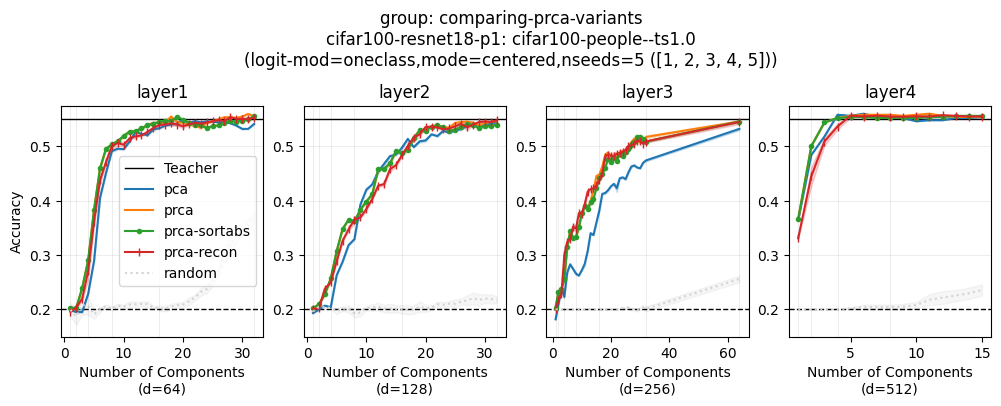

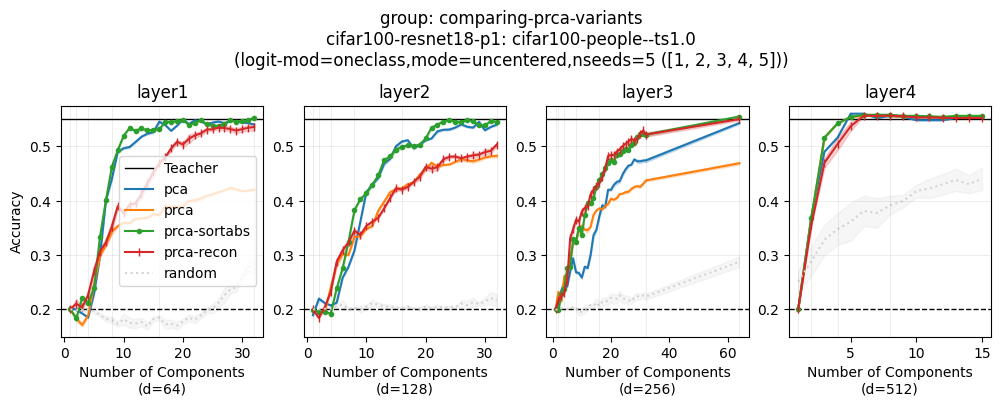

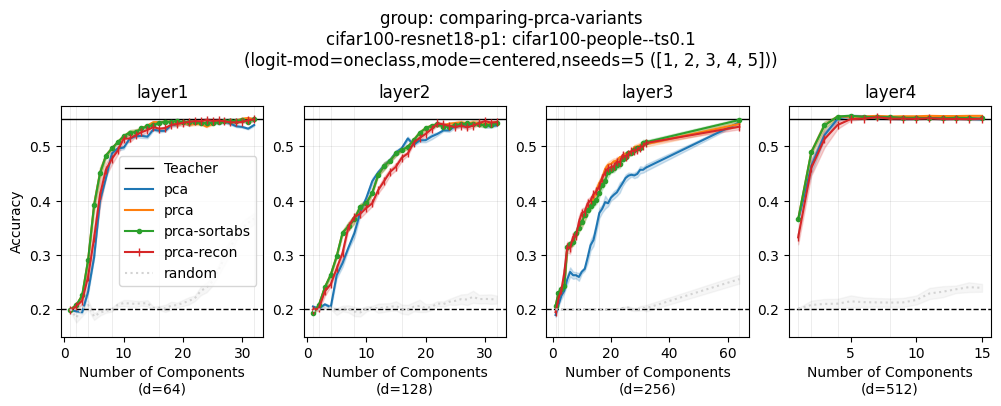

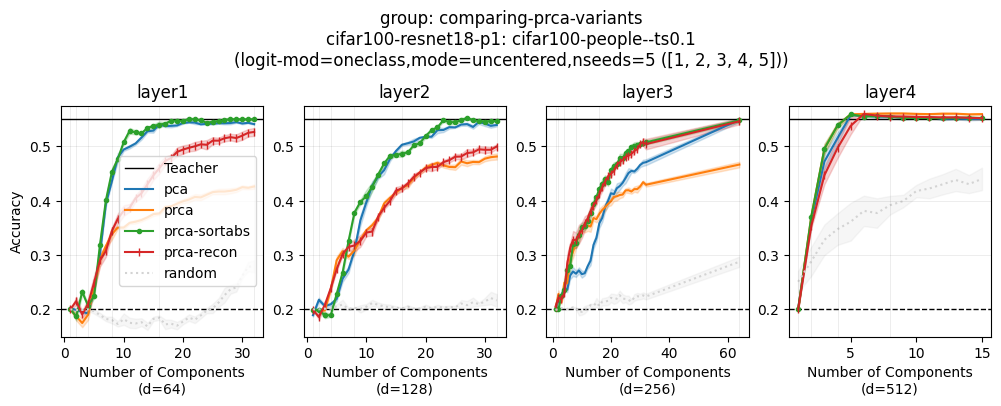

In [44]:
for training_size in [1.0, 0.1]:  
    for basis_mode in ["centered", "uncentered"]:
        viz_oneclass(
            arch="cifar100-resnet18-p1",
            dataset="cifar100-people",
            training_size=training_size,
            basis_mode=basis_mode,
            layers=[
                ("layer1", 1),
                ("layer2", 2),
                ("layer3", 2),
                ("layer4", 32)
            ],
            experiment_group="comparing-prca-variants",
        )

## Comparison on `cifar100-resnet18-wb15`

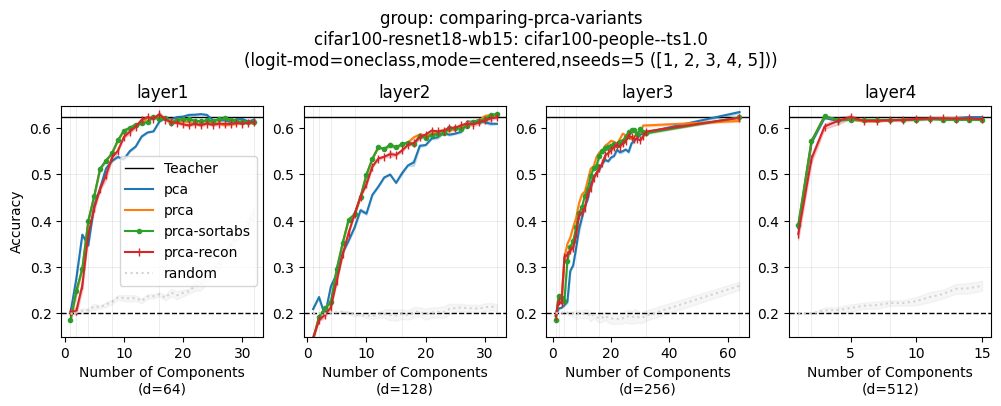

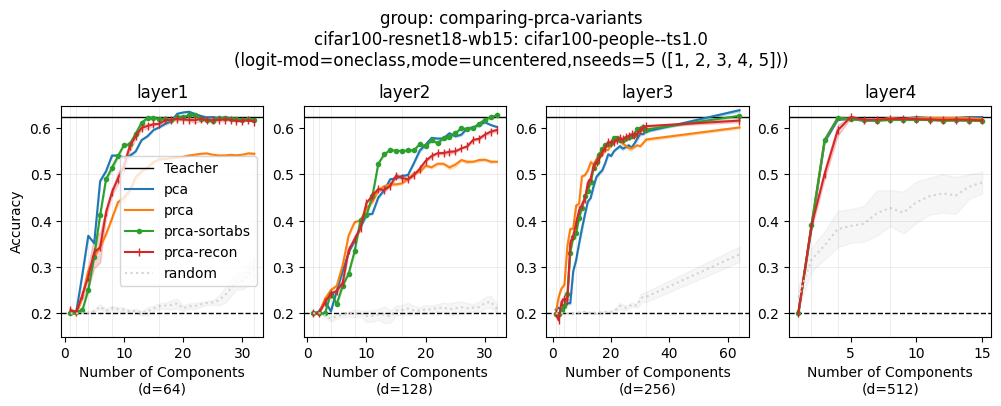

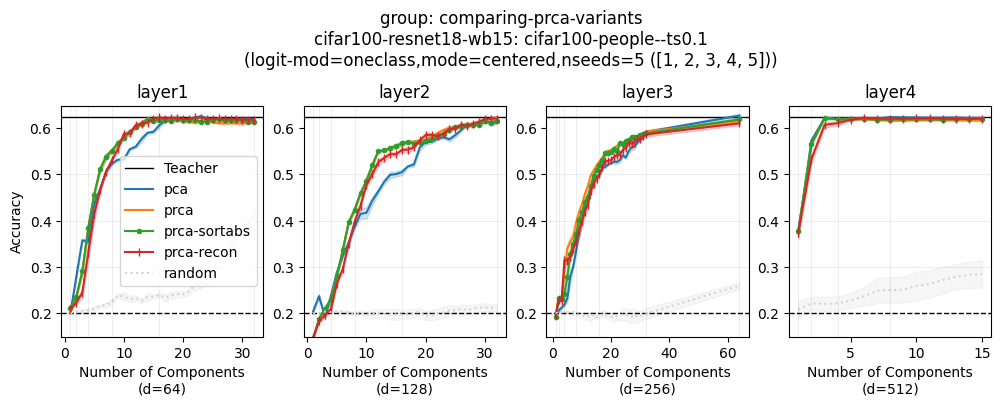

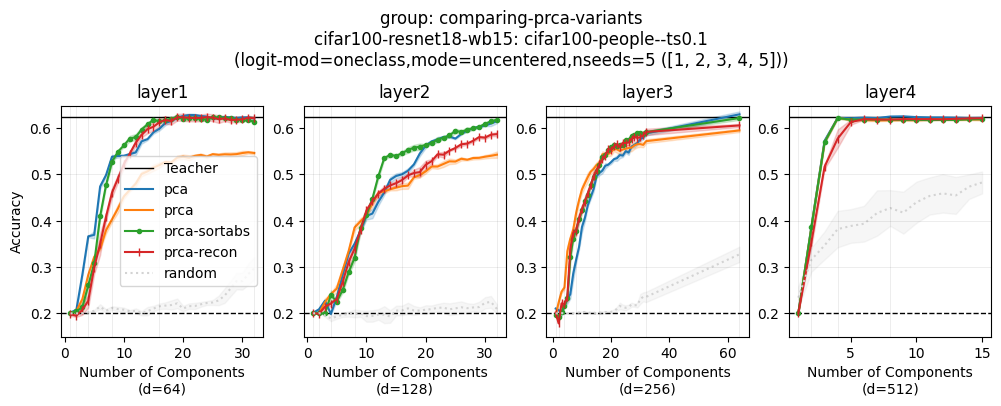

In [45]:
for training_size in [1.0, 0.1]:  
    for basis_mode in ["centered", "uncentered"]:
        viz_oneclass(
            arch="cifar100-resnet18-wb15",
            dataset="cifar100-people",
            training_size=training_size,
            basis_mode=basis_mode,
            layers=[
                ("layer1", 1),
                ("layer2", 2),
                ("layer3", 2),
                ("layer4", 32)
            ],
            experiment_group="comparing-prca-variants",
        )

# CIFAR100-* (1 seed)

In [46]:
CIFAR100_SUPERCLASSES = """
cifar100-aquatic_mammals
cifar100-fish
cifar100-flowers
cifar100-food_containers
cifar100-fruit_and_vegetables
cifar100-household_electrical_devices
cifar100-household_furniture
cifar100-insects
cifar100-large_carnivores
cifar100-large_man_made_outdoor_things
cifar100-large_natural_outdoor_scenes
cifar100-large_omnivores_and_herbivores
cifar100-medium_mammals
cifar100-non_insect_invertebrates
cifar100-people
cifar100-reptiles
cifar100-small_mammals
cifar100-trees
cifar100-vehicles_1
cifar100-vehicles_2
""".strip().split("\n")

CIFAR100_SUPERCLASSES

['cifar100-aquatic_mammals',
 'cifar100-fish',
 'cifar100-flowers',
 'cifar100-food_containers',
 'cifar100-fruit_and_vegetables',
 'cifar100-household_electrical_devices',
 'cifar100-household_furniture',
 'cifar100-insects',
 'cifar100-large_carnivores',
 'cifar100-large_man_made_outdoor_things',
 'cifar100-large_natural_outdoor_scenes',
 'cifar100-large_omnivores_and_herbivores',
 'cifar100-medium_mammals',
 'cifar100-non_insect_invertebrates',
 'cifar100-people',
 'cifar100-reptiles',
 'cifar100-small_mammals',
 'cifar100-trees',
 'cifar100-vehicles_1',
 'cifar100-vehicles_2']

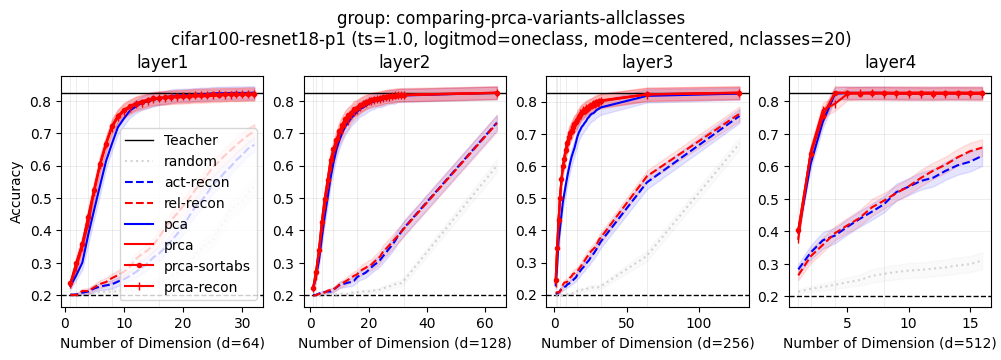

In [82]:
def viz_multiple_classes(
    arch,
    layers_and_factors,
    experiment_group,
    basis_mode,
    arr_classes=CIFAR100_SUPERCLASSES,
    arr_bases = [
        "random",
        "act-recon",
        "rel-recon",
        "pca",
        "prca",
        "prca-sortabs",
        "prca-recon"
    ],
    logit_mod="oneclass",
    disable_color_mapping=False,
    disable_marker_mapping=False
):

    
    training_size = 1.0
    
    ncols = len(layers_and_factors)
    
    plt.figure(figsize=(ncols * 3, 3))
    plt.suptitle("\n".join([
        f"group: {experiment_group}",
        f"{arch} (ts={training_size}, logitmod={logit_mod}, mode={basis_mode}, nclasses={len(arr_classes)})"
    ]), y=1.1)
    
    def color(basis_name):
        if disable_color_mapping:
            return None
        
        if "prca" in basis_name or "rel" in basis_name:
            return "red"
        elif basis_name in ["act-recon", "pca"]:
            return "blue"
        elif "random" == basis_name:
            return "lightgray"
            raise NotImplementedError(f"no color for `{basis_name}`")
            
    def ls(basis_name):
        if basis_name == "random":
            return ":"
        elif basis_name in ["act-recon", "rel-recon"]:
            return "--"
        else:
            return "-"
        
    seeds = [1]
    
    for lix, (layer, factor) in enumerate(layers_and_factors):
        plt.subplot(1, ncols, lix + 1)
        plt.title(layer)

        teacher_stats = []
        for dataset in arr_classes:
            df = load(
                dataset=f"{dataset}--ts{training_size}",  arch=arch, layer=layer, 
                basis_name="random", 
                logit_mod=logit_mod,
                basis_mode=basis_mode,
                experiment_group=experiment_group,
                seeds=seeds
            )
            acc = df["original_acc"]["first"].values
            np.testing.assert_equal(acc[0], acc)
            teacher_stats.append(acc[0])
        
        mean_teacher = np.mean(teacher_stats)
        stderr_teacher = sem(teacher_stats)

        assert mean_teacher.shape == stderr_teacher.shape == ()

        plt.axhline(mean_teacher, label="Teacher", color="k", lw=1, ls="-")
        plt.axhline(0.2, ls="--", lw=1, color="k")

        for basis_name in arr_bases:
            stats = []
            for dataset in arr_classes:
                df = load(
                    dataset=f"{dataset}--ts{training_size}", 
                    arch=arch,
                    layer=layer, 
                    basis_name=basis_name, 
                    logit_mod=logit_mod,
                    basis_mode=basis_mode,
                    experiment_group=experiment_group,
                    seeds=seeds
                )
                                    
                d = df["dims"]["first"].values[0]
                stats.append(df["acc"]["mean"].values)
                k = df["k"].values
            
            stats = np.array(stats)
            
            selected = k <= d//factor
            
            assert stats.shape == (len(arr_classes), len(k))
            
            mean_stats = np.mean(stats, axis=0)
            stderr_stats = sem(stats, axis=0)
            assert stderr_stats.shape == mean_stats.shape

            _k = k[selected]
            _mean = mean_stats[selected]
            _stderr = stderr_stats[selected]
            plt.plot(
                _k,
                _mean, 
                label=basis_name,
                color=color(basis_name),
                ls=ls(basis_name),
                marker=marker(basis_name) if not disable_marker_mapping else None
            )
    
            plt.fill_between(
                _k,
                _mean - _stderr,
                _mean + _stderr,
                color=plt.gca().lines[-1].get_color(),
                alpha=0.1
            )
                                
            
            
            
        
        # plot grid
        for p in np.power(2, np.arange(int(np.log2(d//factor)))):
            if p  > d // factor:   
                continue
            plt.axvline(
                int(p), 
                ls="-", 
                lw=0.5,
                alpha=0.1,
                color="k", 
            )
        for v in [0.4, 0.5, 0.6, 0.7, 0.8]:
            plt.axhline(
                v, 
                ls="-", 
                lw=0.5,
                alpha=0.1,
                color="k", 
            )
            
        plt.xlabel(f"Number of Dimension (d={d})")
        if lix == 0:
            plt.ylabel("Accuracy")
            plt.legend()

viz_multiple_classes(
    arch="cifar100-resnet18-p1",
    experiment_group="comparing-prca-variants-allclasses",
    basis_mode="centered",
    layers_and_factors = [
        ("layer1", 2),
        ("layer2", 2),
        ("layer3", 2),
        ("layer4", 32)
    ]
)

## Comparing PRCA-Variants

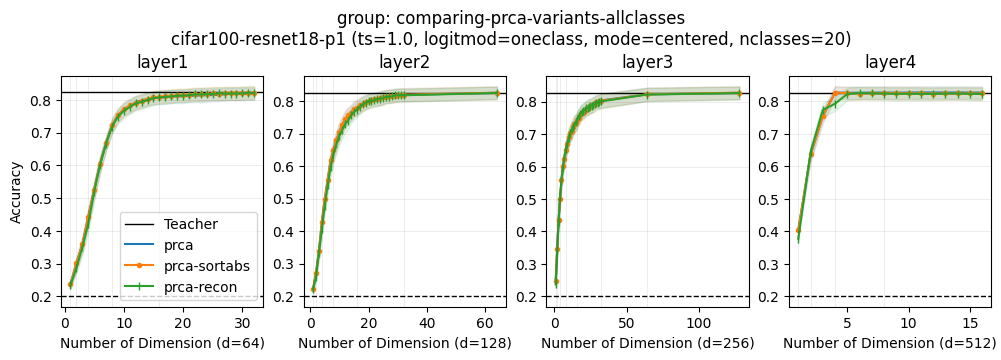

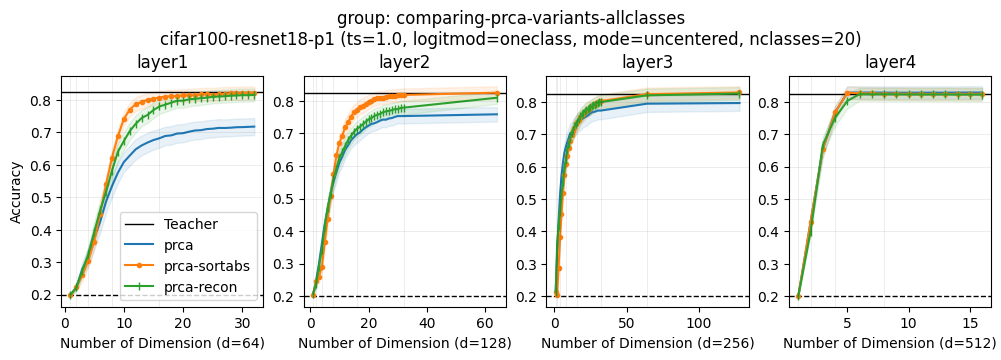

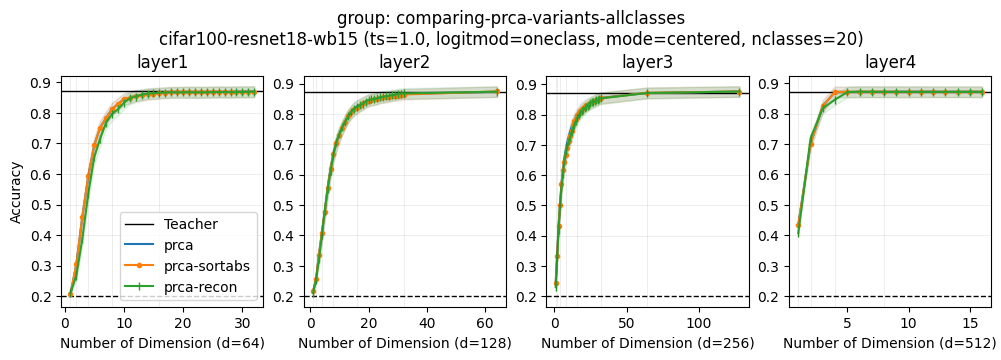

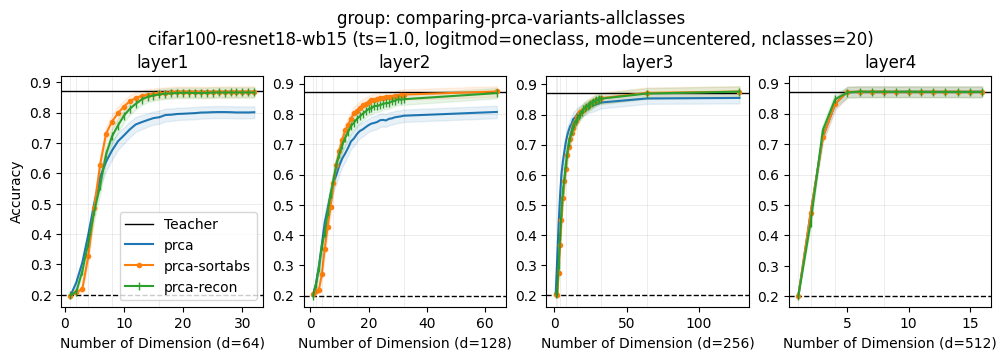

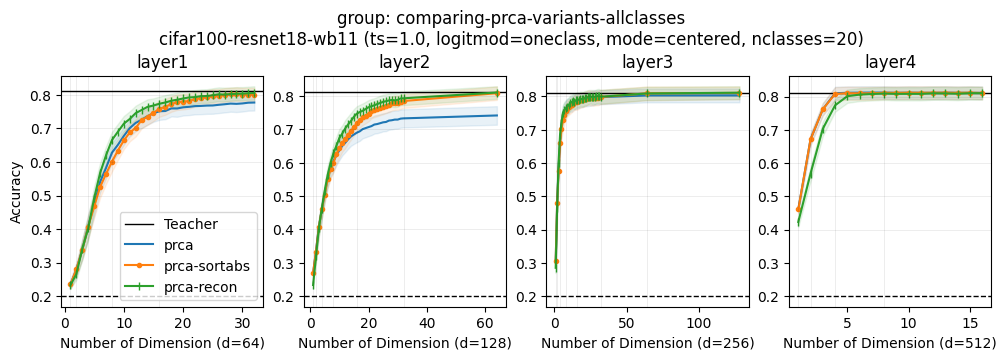

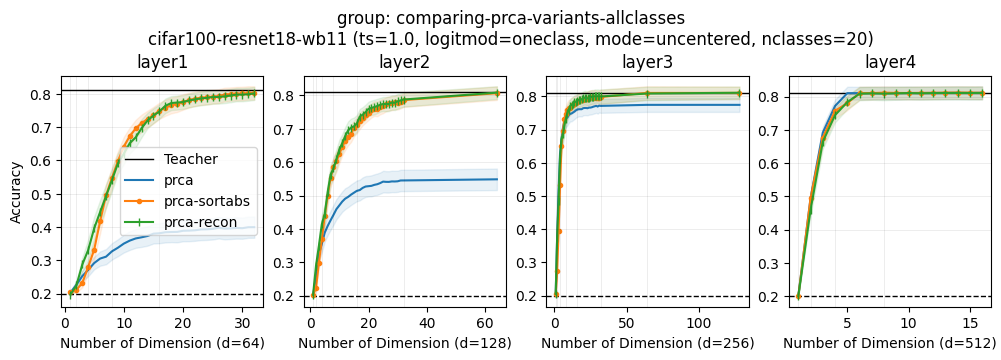

In [93]:
for arch in ["cifar100-resnet18-p1", "cifar100-resnet18-wb15", "cifar100-resnet18-wb11"]:
    for basis_mode in ["centered", "uncentered"]:
        viz_multiple_classes(
            arch=arch,
            experiment_group="comparing-prca-variants-allclasses",
            basis_mode=basis_mode,
            layers_and_factors = [
                ("layer1", 2),
                ("layer2", 2),
                ("layer3", 2),
                ("layer4", 32)
            ],
            arr_bases=['prca', 'prca-sortabs', 'prca-recon'],
            disable_color_mapping=True,
        )

## Comparing All Bases

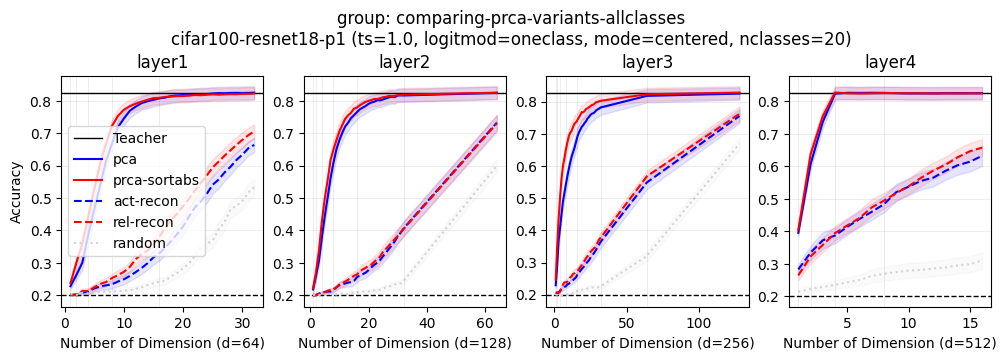

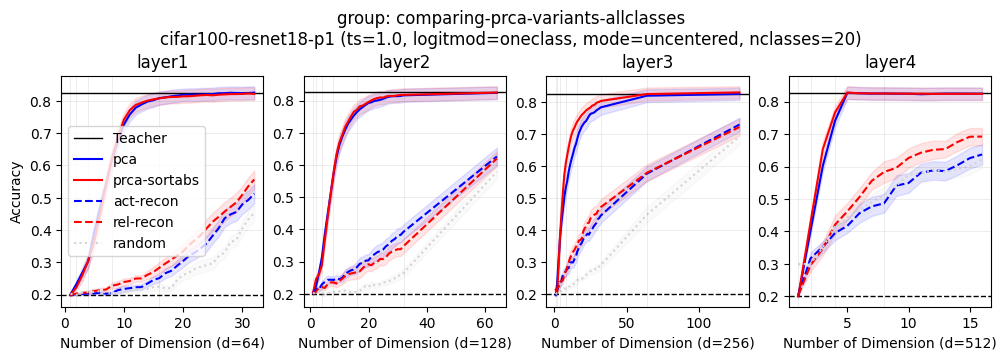

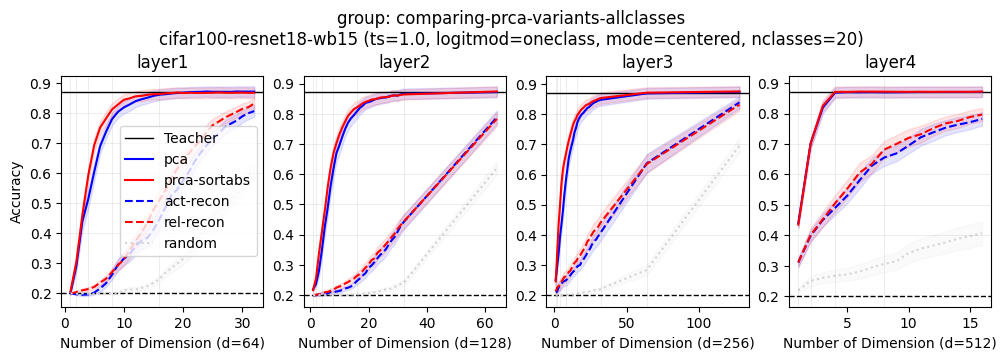

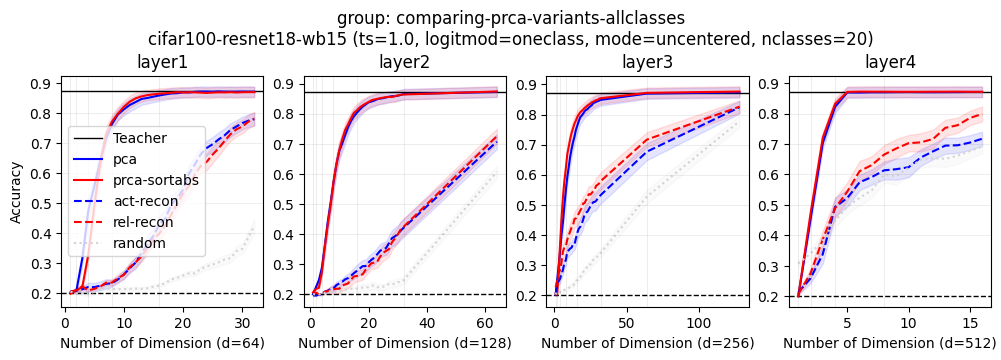

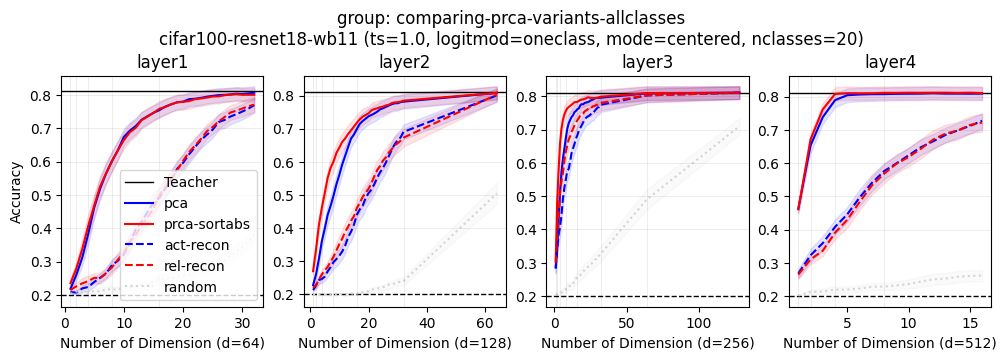

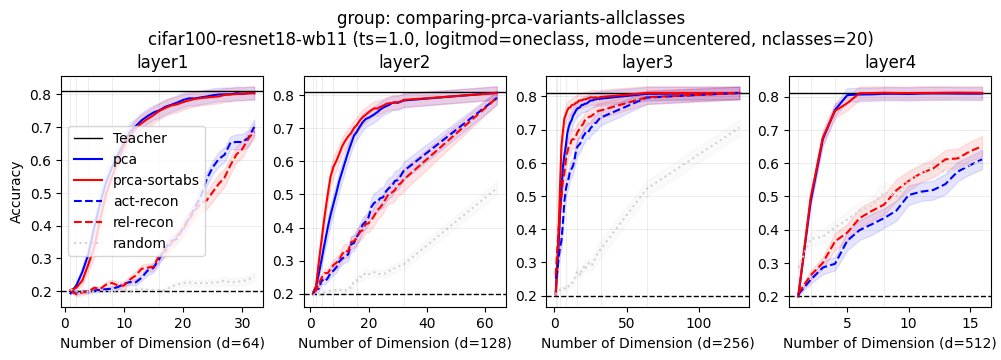

In [92]:
for arch in ["cifar100-resnet18-p1", "cifar100-resnet18-wb15", "cifar100-resnet18-wb11"]:
    for basis_mode in ["centered", "uncentered"]:
        viz_multiple_classes(
            arch=arch,
            experiment_group="comparing-prca-variants-allclasses",
            basis_mode=basis_mode,
            layers_and_factors = [
                ("layer1", 2),
                ("layer2", 2),
                ("layer3", 2),
                ("layer4", 32)
            ],
            arr_bases=['pca', 'prca-sortabs', 'act-recon', 'rel-recon', 'random'],
            disable_marker_mapping=True
        )

# Summary 

## Aim
Here, we aim to compare different variants of PRCA. In particular, we particularly focus on the closed-form variant `prca` and `prca-v2` (sorted by absolute eigenvalues).

## Independent Variables
- architecture: `{cifar100-resnet18-p1, cifar100-resnet18-wb15}`
- model: `{centered, uncentered}`
- training-size: `{1.0, 0.1}`

## Conclusion

### Comparison of PRCA-Variants
- `prca-sortabs` is the best variant regardless whether `centering` or `noncentering`.
- the performance of `prca` is highly influenced by centering. More precisely, `prca` only works well when we perform `centering`.


### `Centered` vs `Uncentered`

- for `act-recon`, its `centered` result seem better than `uncentered`.
- for orthogonal bases like `pca,prca-sortabs`, centering does NOT seem to have any effect.
    - this is too good to be true.


## Follow-up
- replication on other CIFAR100 superclasses
- analysis on PRCA-v2 spectrum. 
- is there any theothetical justification?  